# Analyse des résultats du Mini-ETL

**Projet de pipeline automatisé — Python, DuckDB, API Flask, Visualisation**

- Ce notebook valorise les résultats créés automatiquement par le pipeline Mini-ETL.
- Données sources : *data/products.csv*  
- Exports utilisés : `exports/clean_data.csv`, `exports/prix_par_produit.csv`, `exports/indicateurs.csv`, etc.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 10)

## Indicateurs clés du catalogue

Ce tableau présente les **KPI principaux** extraits du pipeline :
- Prix total de l’ensemble du catalogue,
- Nombre de produits distincts,
- Marge totale générée.

In [33]:
df_kpi = pd.read_csv('exports/indicateurs.csv')
df_kpi

,kpi,valeur
0,prix_total,143562.4
1,nb_produits,1197.0
2,marge_totale,50643.5


## Aperçu du jeu de données nettoyé

Voici les premières lignes du jeu de données propre obtenu après le nettoyage automatisé (doublons, valeurs manquantes...).

In [34]:
df_clean = pd.read_csv('exports/clean_data.csv')
print(df_clean.columns)
df_clean.head()

Index(['product_id', 'category', 'name', 'price_usd', 'cost_usd',
       'margin_usd'],
      dtype='str')


,product_id,category,name,price_usd,cost_usd,margin_usd
0,1,Electronics,Ssd Mediumblue 149,570.28,352.69,217.59
1,2,Electronics,Keyboard Deeppink 696,498.13,263.13,235.00
2,3,Electronics,Headphones Orchid 188,548.53,309.60,238.93
3,4,Electronics,Smartwatch Burlywood 664,268.36,153.56,114.80
4,5,Electronics,Smartwatch Cornsilk 328,63.69,42.65,21.04


## Top 10 produits par prix total

Ce graphique permet d’identifier les **10 produits** ayant généré le chiffre d’affaires le plus élevé.

Index(['name', 'price_usd'], dtype='str')


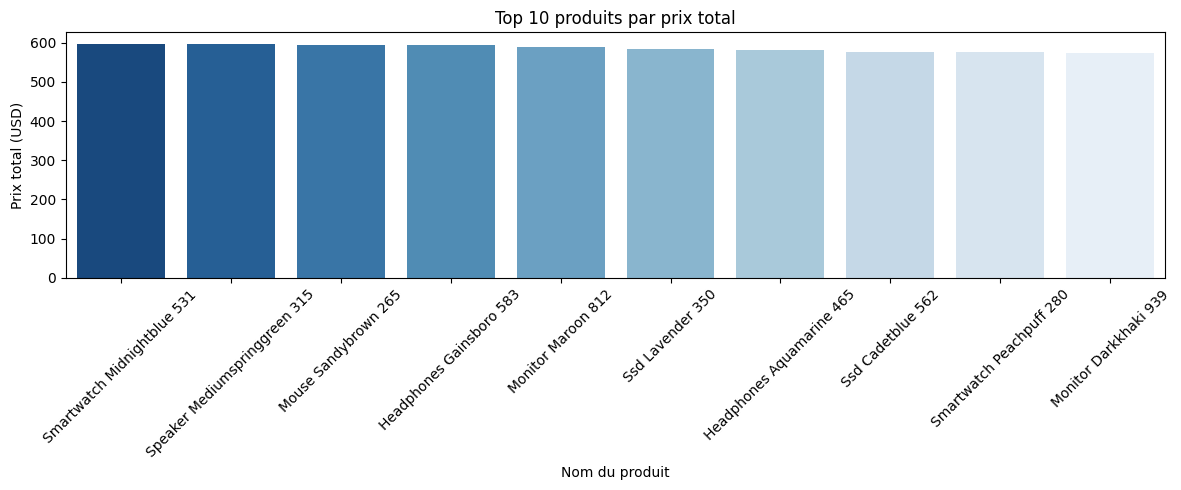

In [35]:
df_agg = pd.read_csv('exports/prix_par_produit.csv')
print(df_agg.columns)

# Pour la lisibilité, affiche TOP 10 produits par prix
df_top10 = df_agg.sort_values('price_usd', ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=df_top10, x="name", y="price_usd", palette="Blues_r")
plt.title("Top 10 produits par prix total")
plt.xlabel("Nom du produit")
plt.ylabel("Prix total (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Liste des produits les plus chers

Ci-dessous la liste de tous les produits dont le **prix unitaire dépasse 500 dollars**.  
Cela permet d’identifier les produits premium du catalogue.

In [37]:
df_cher = pd.read_csv('exports/produits_chers.csv')
print(df_cher.columns)
print(df_cher.head())

Index(['id', 'produit', 'prix'], dtype='str')
   id produit  prix
0   2  Carnet   4.0


In [28]:
df_clean = pd.read_csv('exports/clean_data.csv')
# Afficher tous les produits d'un prix > 500 USD (par exemple)
df_cher = df_clean[df_clean['price_usd'] > 500][['product_id', 'name', 'price_usd', 'margin_usd']]
df_cher.head(10)

,product_id,name,price_usd,margin_usd
0,1,Ssd Mediumblue 149,570.28,217.59
2,3,Headphones Orchid 188,548.53,238.93
16,17,Mouse Lawngreen 784,561.96,209.89
27,28,Monitor Darkslateblue 984,533.53,135.63
29,30,Smartwatch Peachpuff 280,575.91,261.88
45,46,Monitor Maroon 812,587.75,141.65
51,52,Headphones Gainsboro 583,594.07,156.22
57,58,Keyboard Mediumspringgreen 497,505.75,234.68
66,67,Webcam Deeppink 357,500.91,218.74
69,70,Headphones Blueviolet 569,548.71,216.12


## Répartition du prix total par catégorie

Ce graphique montre la contribution de chaque catégorie de produit au chiffre d'affaires total.

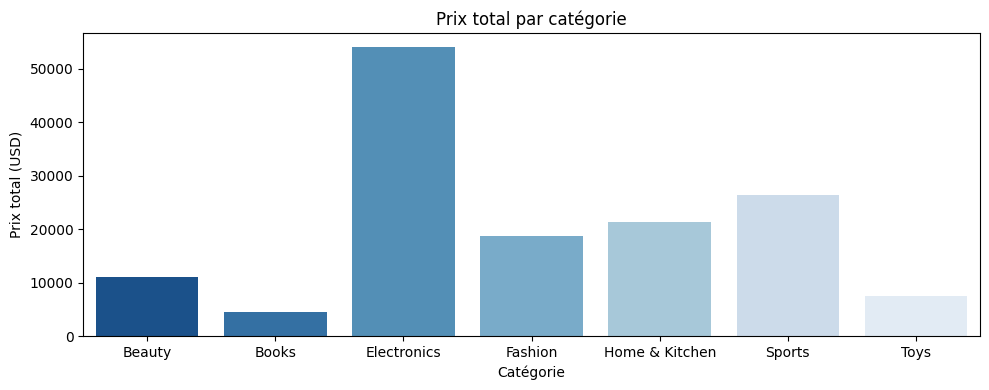

In [29]:
df_categ = pd.read_csv('exports/prix_par_categorie.csv')
plt.figure(figsize=(10,4))
sns.barplot(data=df_categ, x="category", y="price_usd", palette="Blues_r")
plt.title("Prix total par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Prix total (USD)")
plt.tight_layout()
plt.show()

---

## Conclusion

Ce notebook permet de contrôler visuellement et d’expliquer les résultats du pipeline automatisé Mini-ETL :
- Les indicateurs sont calculés automatiquement sur toutes les données importées,
- Les visualisations sont adaptables à tout nouveau dataset : il suffit de relancer le pipeline,
- L’ensemble des étapes est reproductible et transparent.

➡️ **Prochaines évolutions possibles** : analyses plus avancées, intégration de scores divers, branchement sur un front web, etc.